# Preprocesiranje 

In [23]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from torch.utils.data import WeightedRandomSampler

### Resize

In [7]:
ulazni_dataset = 'dataset'
izlazni_dataset = 'dataset_224x224'

kategorije = sorted([k for k in os.listdir(ulazni_dataset) if os.path.isdir(os.path.join(ulazni_dataset, k))])

for kategorija in tqdm(kategorije):
    for split in ['train', 'test']:
        split_putanja = os.path.join(ulazni_dataset, kategorija, split)
        for podfolder in os.listdir(split_putanja):
            ulaz = os.path.join(split_putanja, podfolder)
            izlaz = os.path.join(izlazni_dataset, kategorija, split, podfolder)
            os.makedirs(izlaz, exist_ok=True)
            for naziv in os.listdir(ulaz):
                slika = Image.open(os.path.join(ulaz, naziv)).convert("RGB")
                slika = slika.resize((224, 224))
                slika.save(os.path.join(izlaz, naziv))

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [08:25<00:00, 33.70s/it]


In [8]:
dataset = 'dataset_224x224'

kategorije = sorted([k for k in os.listdir(dataset) if os.path.isdir(os.path.join(dataset, k))])

print(f"Kategorije: {kategorije}")

Kategorije: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


### Sumiranje podataka

In [10]:
print(f"{'Kategorija':15} | {'Train good':10} | {'Test good':9} | {'Test defekt':11} | {'Ukupno':6}")
print("-" * 60)

ukupno_train = 0
ukupno_test_good = 0
ukupno_test_defekt = 0

for kategorija in kategorije:
    train_good = os.path.join(dataset, kategorija, "train", "good")
    test_putanja = os.path.join(dataset, kategorija, "test")

    broj_train = len(os.listdir(train_good))
    broj_test_good = 0
    broj_test_defekt = 0

    for podfolder in os.listdir(test_putanja):
        puna_putanja = os.path.join(test_putanja, podfolder)
        if podfolder == "good":
            broj_test_good += len(os.listdir(puna_putanja))
        else:
            broj_test_defekt += len(os.listdir(puna_putanja))

    ukupno = broj_train + broj_test_good + broj_test_defekt
    ukupno_train += broj_train
    ukupno_test_good += broj_test_good
    ukupno_test_defekt += broj_test_defekt

    print(f"{kategorija:15} | {broj_train:10} | {broj_test_good:9} | {broj_test_defekt:11} | {ukupno:6}")

print("-" * 60)
print(f"{'UKUPNO':15} | {ukupno_train:10} | {ukupno_test_good:9} | {ukupno_test_defekt:11} | {ukupno_train+ukupno_test_good+ukupno_test_defekt:6}")    

Kategorija      | Train good | Test good | Test defekt | Ukupno
------------------------------------------------------------
bottle          |        209 |        20 |          63 |    292
cable           |        224 |        58 |          92 |    374
capsule         |        219 |        23 |         109 |    351
carpet          |        280 |        28 |          89 |    397
grid            |        264 |        21 |          57 |    342
hazelnut        |        391 |        40 |          70 |    501
leather         |        245 |        32 |          92 |    369
metal_nut       |        220 |        22 |          93 |    335
pill            |        267 |        26 |         141 |    434
screw           |        320 |        41 |         119 |    480
tile            |        230 |        33 |          84 |    347
toothbrush      |         60 |        12 |          30 |    102
transistor      |        213 |        60 |          40 |    313
wood            |        247 |        19 | 

### Prikaz good vs defekt

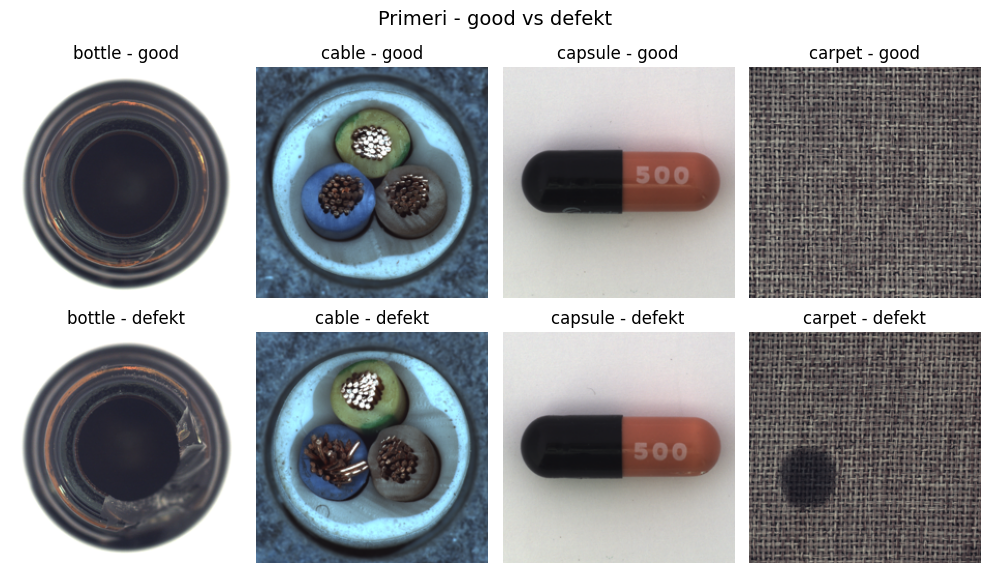

In [17]:
prikazane_kategorije = kategorije[:4]

fig, ose = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("Primeri - good vs defekt", fontsize=14)

for i, kategorija in enumerate(prikazane_kategorije):
    
    test_putanja = os.path.join(dataset, kategorija, "test")
    good_putanja = os.path.join(test_putanja, "good")

    slika = Image.open(os.path.join(good_putanja, os.listdir(good_putanja)[0]))

    ose[0, i].imshow(slika)
    ose[0, i].set_title(f"{kategorija} - good")
    ose[0, i].axis("off")

    defekt_folder = [f for f in os.listdir(test_putanja) if f != "good"][0]
    defekt_putanja = os.path.join(test_putanja, defekt_folder)

    slika = Image.open(os.path.join(defekt_putanja, os.listdir(defekt_putanja)[0]))

    ose[1, i].imshow(slika)
    ose[1, i].set_title(f"{kategorija} - defekt")
    ose[1, i].axis("off")

plt.tight_layout()
plt.show()

### Dataset klasa

In [33]:
class MVTecDataset(Dataset):
    def __init__(self, putanja_dataseta, transformacija=None, mod="train"):
        super().__init__()
        self.transformacija = transformacija
        self.podaci = []
        
        kategorije = sorted([k for k in os.listdir(putanja_dataseta) if os.path.isdir(os.path.join(putanja_dataseta, k))])

        for kategorija in kategorije:
            if mod == "train":
                good_putanja = os.path.join(putanja_dataseta, kategorija, "train", "good")
                for naziv_slike in os.listdir(good_putanja):
                    self.podaci.append((os.path.join(good_putanja, naziv_slike), 0))

                test_putanja = os.path.join(putanja_dataseta, kategorija, "test")
                for podfolder in os.listdir(test_putanja):
                    if podfolder != "good":
                        puna_putanja = os.path.join(test_putanja, podfolder)
                        slike = os.listdir(puna_putanja)
                        train_deo = int(len(slike) * 0.7)
                        for naziv_slike in slike[:train_deo]:
                            self.podaci.append((os.path.join(puna_putanja, naziv_slike), 1))

            elif mod == "test":
                test_putanja = os.path.join(putanja_dataseta, kategorija, "test")
                for podfolder in os.listdir(test_putanja):
                    puna_putanja = os.path.join(test_putanja, podfolder)
                    slike = os.listdir(puna_putanja)
                    if podfolder == "good":
                        for naziv_slike in slike:
                            self.podaci.append((os.path.join(puna_putanja, naziv_slike), 0))

                    else:
                        test_deo = int(len(slike) * 0.7)
                        for naziv_slike in slike[test_deo:]:
                            self.podaci.append((os.path.join(puna_putanja, naziv_slike), 1))

        np.random.shuffle(self.podaci)
        print(f"[{mod}] Ukupno slika: {len(self.podaci)}")

    def __len__(self):
        return len(self.podaci)
    
    def __getitem__(self, indeks):
        putanja, labela = self.podaci[indeks]
        slika = Image.open(putanja).convert("RGB")
        if self.transformacija:
            slika = self.transformacija(slika)
        return slika, labela

### Transformacija, DataLoader i provera

In [34]:
transformacija = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = MVTecDataset(dataset, transformacija=transformacija, mod="train")
test_dataset = MVTecDataset(dataset, transformacija=transformacija, mod="test")

labele = [l for _, l in train_dataset.podaci]
print(f"Train - good: {labele.count(0)}, defekt: {labele.count(1)}")

tezine = torch.DoubleTensor([1.0/labele.count(0) if l == 0 else 1.0/labele.count(1) for l in labele])

sampler = WeightedRandomSampler(tezine, num_samples=len(tezine), replacement=True)

train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

uredjaj = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(uredjaj)
print(torch.cuda.get_device_name(0))

slike, labele = next(iter(train_dataloader))
print(f"Oblik batcha: {slike.shape}")

[train] Ukupno slika: 4478
[test] Ukupno slika: 876
Train - good: 3629, defekt: 849
cuda
NVIDIA GeForce RTX 3060 Ti
Oblik batcha: torch.Size([128, 3, 224, 224])
